## Question:
Can I predict a persons reaction time based on what sport they play?

## Type of study
My study is an observational study because I am only looking at 2 collums not the whole study. My 2 collums are sport they play or activity and how quick is there reaction time. Which makes it an observational study. It is also only a very small group of students and is a sample of students. This sample is not repersented to the students within the United States.

In [1]:
import pandas as pd
from tabulate import tabulate
import seaborn as sns
import pandas as pd 
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("school.csv")
df.head()

,Country,Region,DataYear,ClassGrade,Gender,Ageyears,Handed,Height_cm,Footlength_cm,Armspan_cm,...,Watching_TV_Hours,Paid_Work_Hours,Work_At_Home_Hours,Schoolwork_Pressure,Planned_Education_Level,Favorite_Music,Superpower,Preferred_Status,Role_Model_Type,Charity_Donation
0,USA,SC,2013,11,Male,17.0,Right-Handed,180,26,180,...,2,20,10,NaN,Graduate degree,Country,Invisibility,Rich,Relative,Health
1,USA,CA,2016,12,Female,17.0,Right-Handed,170,24,162.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,USA,WA,2025,12,Male,17.0,Right-Handed,182,26.5,176,...,0,0,3,Some,High school,Rock and roll,Freeze time,Healthy,Other,Other
3,USA,TN,2015,12,Male,17.0,Right-Handed,180,30,184,...,5,35,5,Very little,Graduate degree,Country,Fly,Happy,Friend,Other
4,USA,MA,2019,11,Male,16.0,Right-Handed,174.5,27,182,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df["Reaction_time"] = pd.to_numeric(df["Reaction_time"], errors="coerce")

In [4]:
clean_df = df.dropna(subset=["Favourite_physical_activity", "Reaction_time"])

In [5]:
Stats_By_Sport = (clean_df.groupby("Favourite_physical_activity")["Reaction_time"].agg(["count", "mean", "std"]).reset_index())

In [6]:
print("--- Reaction Time Statistics by Favorite Sport ---")
print(Stats_By_Sport)

--- Reaction Time Statistics by Favorite Sport ---
    Favourite_physical_activity  count       mean        std
0                     Athletics     27  11.162926  54.931921
1             Baseball/Softball     26   0.718038   1.157821
2                    Basketball     49   8.060163  51.483631
3                       Bowling      2   0.396000   0.175362
4                       Cycling      6   0.490667   0.182358
5                       Dancing     38  10.558947  62.051269
6           Football (American)     30   0.625400   0.921012
7                          Golf     13   0.512000   0.311544
8                    Gymnastics      4   0.485000   0.247670
9                Hockey (Field)      3   0.505000   0.281736
10                 Hockey (Ice)      2   0.342500   0.038891
11                     Lacrosse      7   0.470714   0.204272
12                 Martial Arts     10   0.488900   0.167214
13                        Other     86   0.556058   0.828997
14                       Rowing   

In [7]:
clean_df["Reaction_Time_Interval"] = pd.qcut(clean_df["Reaction_time"], q=3)


clean_df["Reaction_Time_Interval"] = clean_df["Reaction_Time_Interval"].apply(lambda x: f"{x.left:.2f}s – {x.right:.2f}s")


table = pd.crosstab(index=clean_df["Favourite_physical_activity"], columns=clean_df["Reaction_Time_Interval"], margins=True, margins_name="Totals",)


table.index.name = "Sports"


print("\n" + "=" * 60)
print(" REACTION TIME BY SPORT ".center(60, "="))
print("=" * 60)
print(tabulate(table, headers="keys", tablefmt="fancy_grid"))


================== REACTION TIME BY SPORT ==================
╒═════════════════════════════╤══════════════════╤═════════════════╤═══════════════════╤══════════╕
│ Sports                      │   -0.00s – 0.35s │   0.35s – 0.45s │   0.45s – 383.00s │   Totals │
╞═════════════════════════════╪══════════════════╪═════════════════╪═══════════════════╪══════════╡
│ Athletics                   │                5 │              12 │                10 │       27 │
├─────────────────────────────┼──────────────────┼─────────────────┼───────────────────┼──────────┤
│ Baseball/Softball           │                9 │               8 │                 9 │       26 │
├─────────────────────────────┼──────────────────┼─────────────────┼───────────────────┼──────────┤
│ Basketball                  │               20 │              10 │                19 │       49 │
├─────────────────────────────┼──────────────────┼─────────────────┼───────────────────┼──────────┤
│ Bowling                     │       

## Athletics collum using desmos calculator
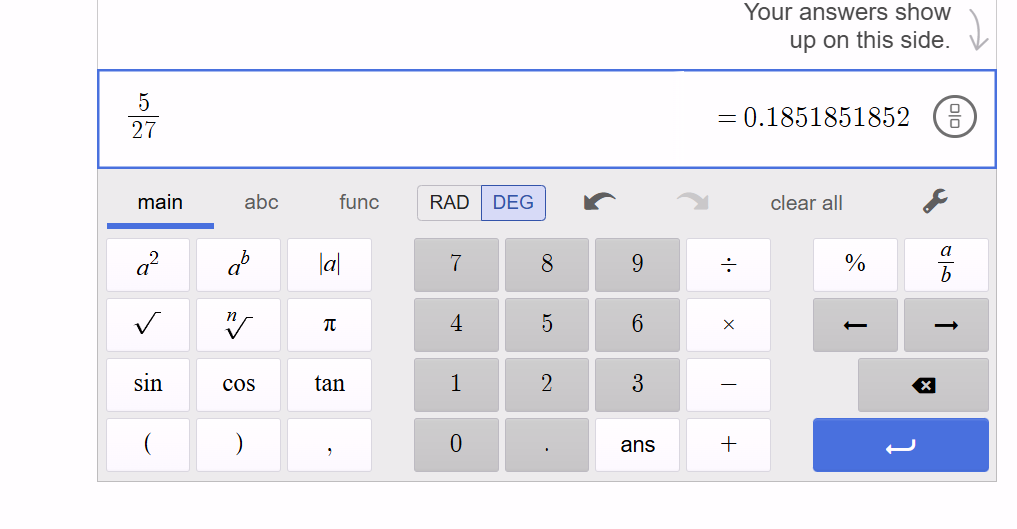
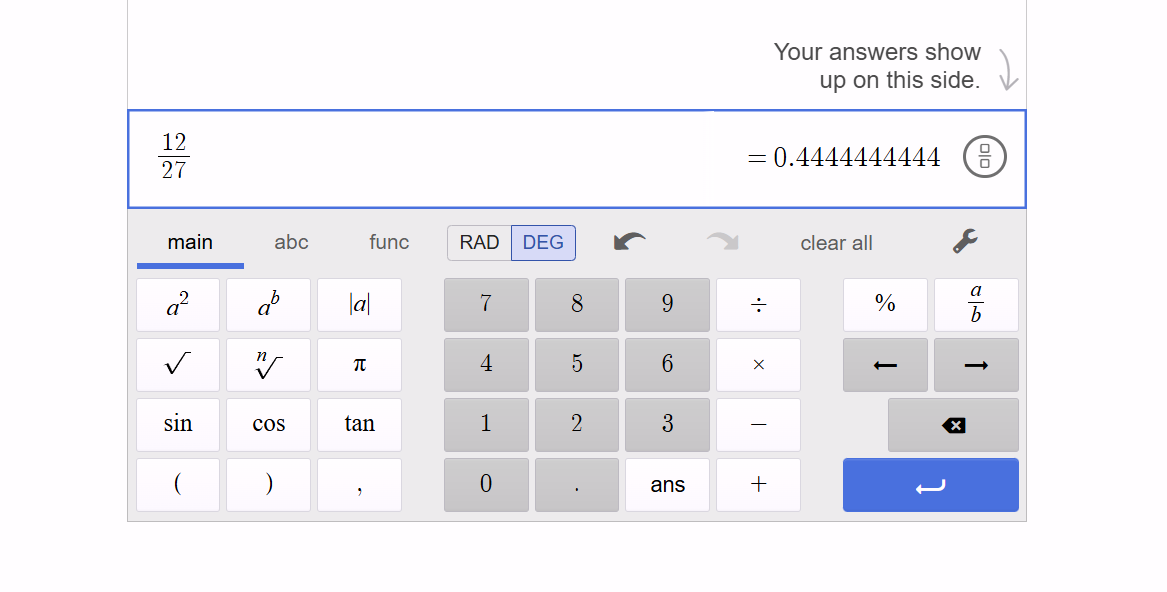
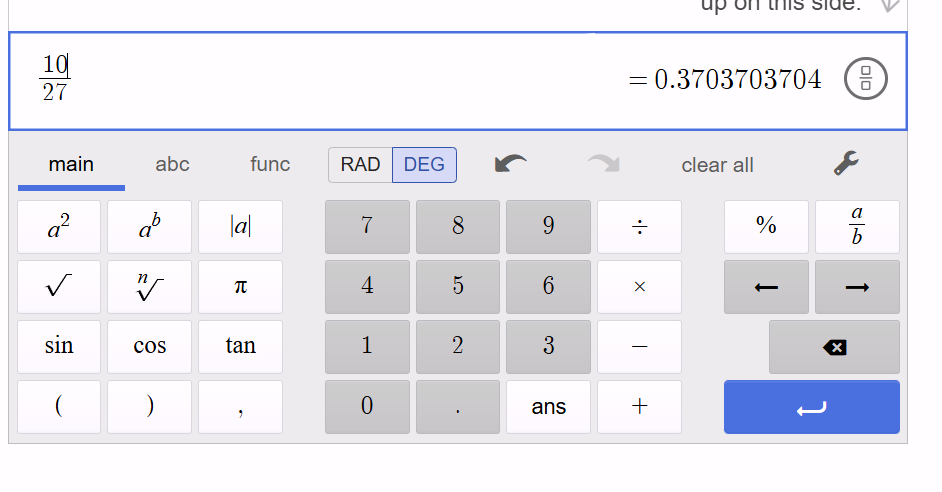

In [8]:
clean_df["Reaction_Time_Interval"] = pd.qcut(clean_df["Reaction_time"], q=3)


clean_df["Reaction_Time_Interval"] = clean_df["Reaction_Time_Interval"].apply(lambda x: f"{x.left:.2f}s – {x.right:.2f}s")


table = pd.crosstab(index=clean_df["Favourite_physical_activity"], columns=clean_df["Reaction_Time_Interval"], normalize="index", margins=True, margins_name="Totals",)

table.index.name = "Sports"

formatted_table = table.map(lambda x: f"{x * 100:.1f}%")

print("\n" + "=" * 60)
print(" CONDITIONAL RELATIVE FREQUENCY BY SPORT ".center(60, "="))
print("=" * 60)
print(tabulate(formatted_table, headers="keys", tablefmt="fancy_grid"))


========= CONDITIONAL RELATIVE FREQUENCY BY SPORT ==========
╒═════════════════════════════╤══════════════════╤═════════════════╤═══════════════════╕
│ Sports                      │ -0.00s – 0.35s   │ 0.35s – 0.45s   │ 0.45s – 383.00s   │
╞═════════════════════════════╪══════════════════╪═════════════════╪═══════════════════╡
│ Athletics                   │ 18.5%            │ 44.4%           │ 37.0%             │
├─────────────────────────────┼──────────────────┼─────────────────┼───────────────────┤
│ Baseball/Softball           │ 34.6%            │ 30.8%           │ 34.6%             │
├─────────────────────────────┼──────────────────┼─────────────────┼───────────────────┤
│ Basketball                  │ 40.8%            │ 20.4%           │ 38.8%             │
├─────────────────────────────┼──────────────────┼─────────────────┼───────────────────┤
│ Bowling                     │ 50.0%            │ 0.0%            │ 50.0%             │
├─────────────────────────────┼─────────────────

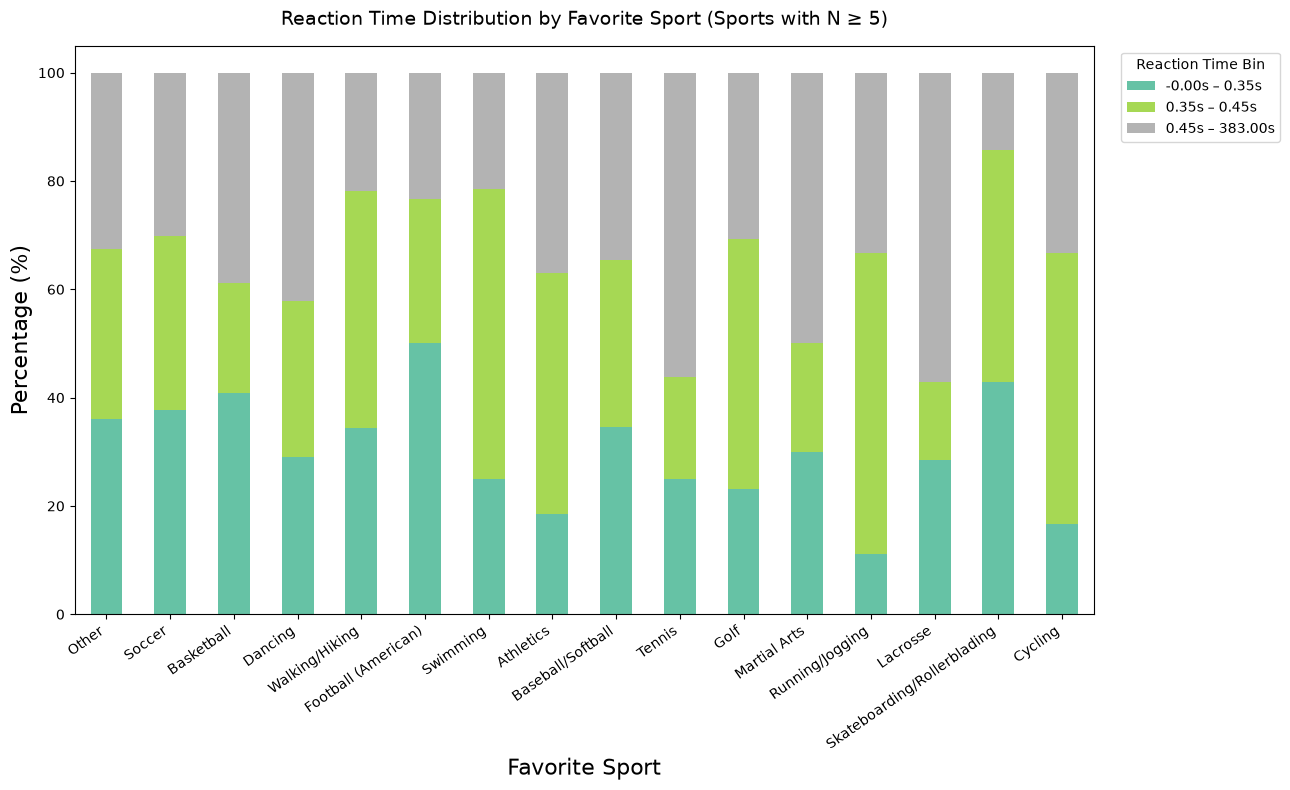

In [9]:
table = pd.crosstab(index=clean_df["Favourite_physical_activity"], columns=clean_df["Reaction_Time_Interval"], normalize="index",)

sport_counts = clean_df["Favourite_physical_activity"].value_counts()
major_sports = sport_counts[sport_counts >= 5].index 
filtered_table = table.loc[major_sports]

ax = (filtered_table * 100).plot(kind="bar", stacked=True, figsize=(13, 8), colormap="Set2")

plt.title("Reaction Time Distribution by Favorite Sport (Sports with N ≥ 5)", fontsize=14, pad=15,)

plt.xlabel("Favorite Sport", fontsize=16)
plt.ylabel("Percentage (%)", fontsize=16)
plt.xticks(rotation=35, ha="right")
plt.legend(title="Reaction Time Bin", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 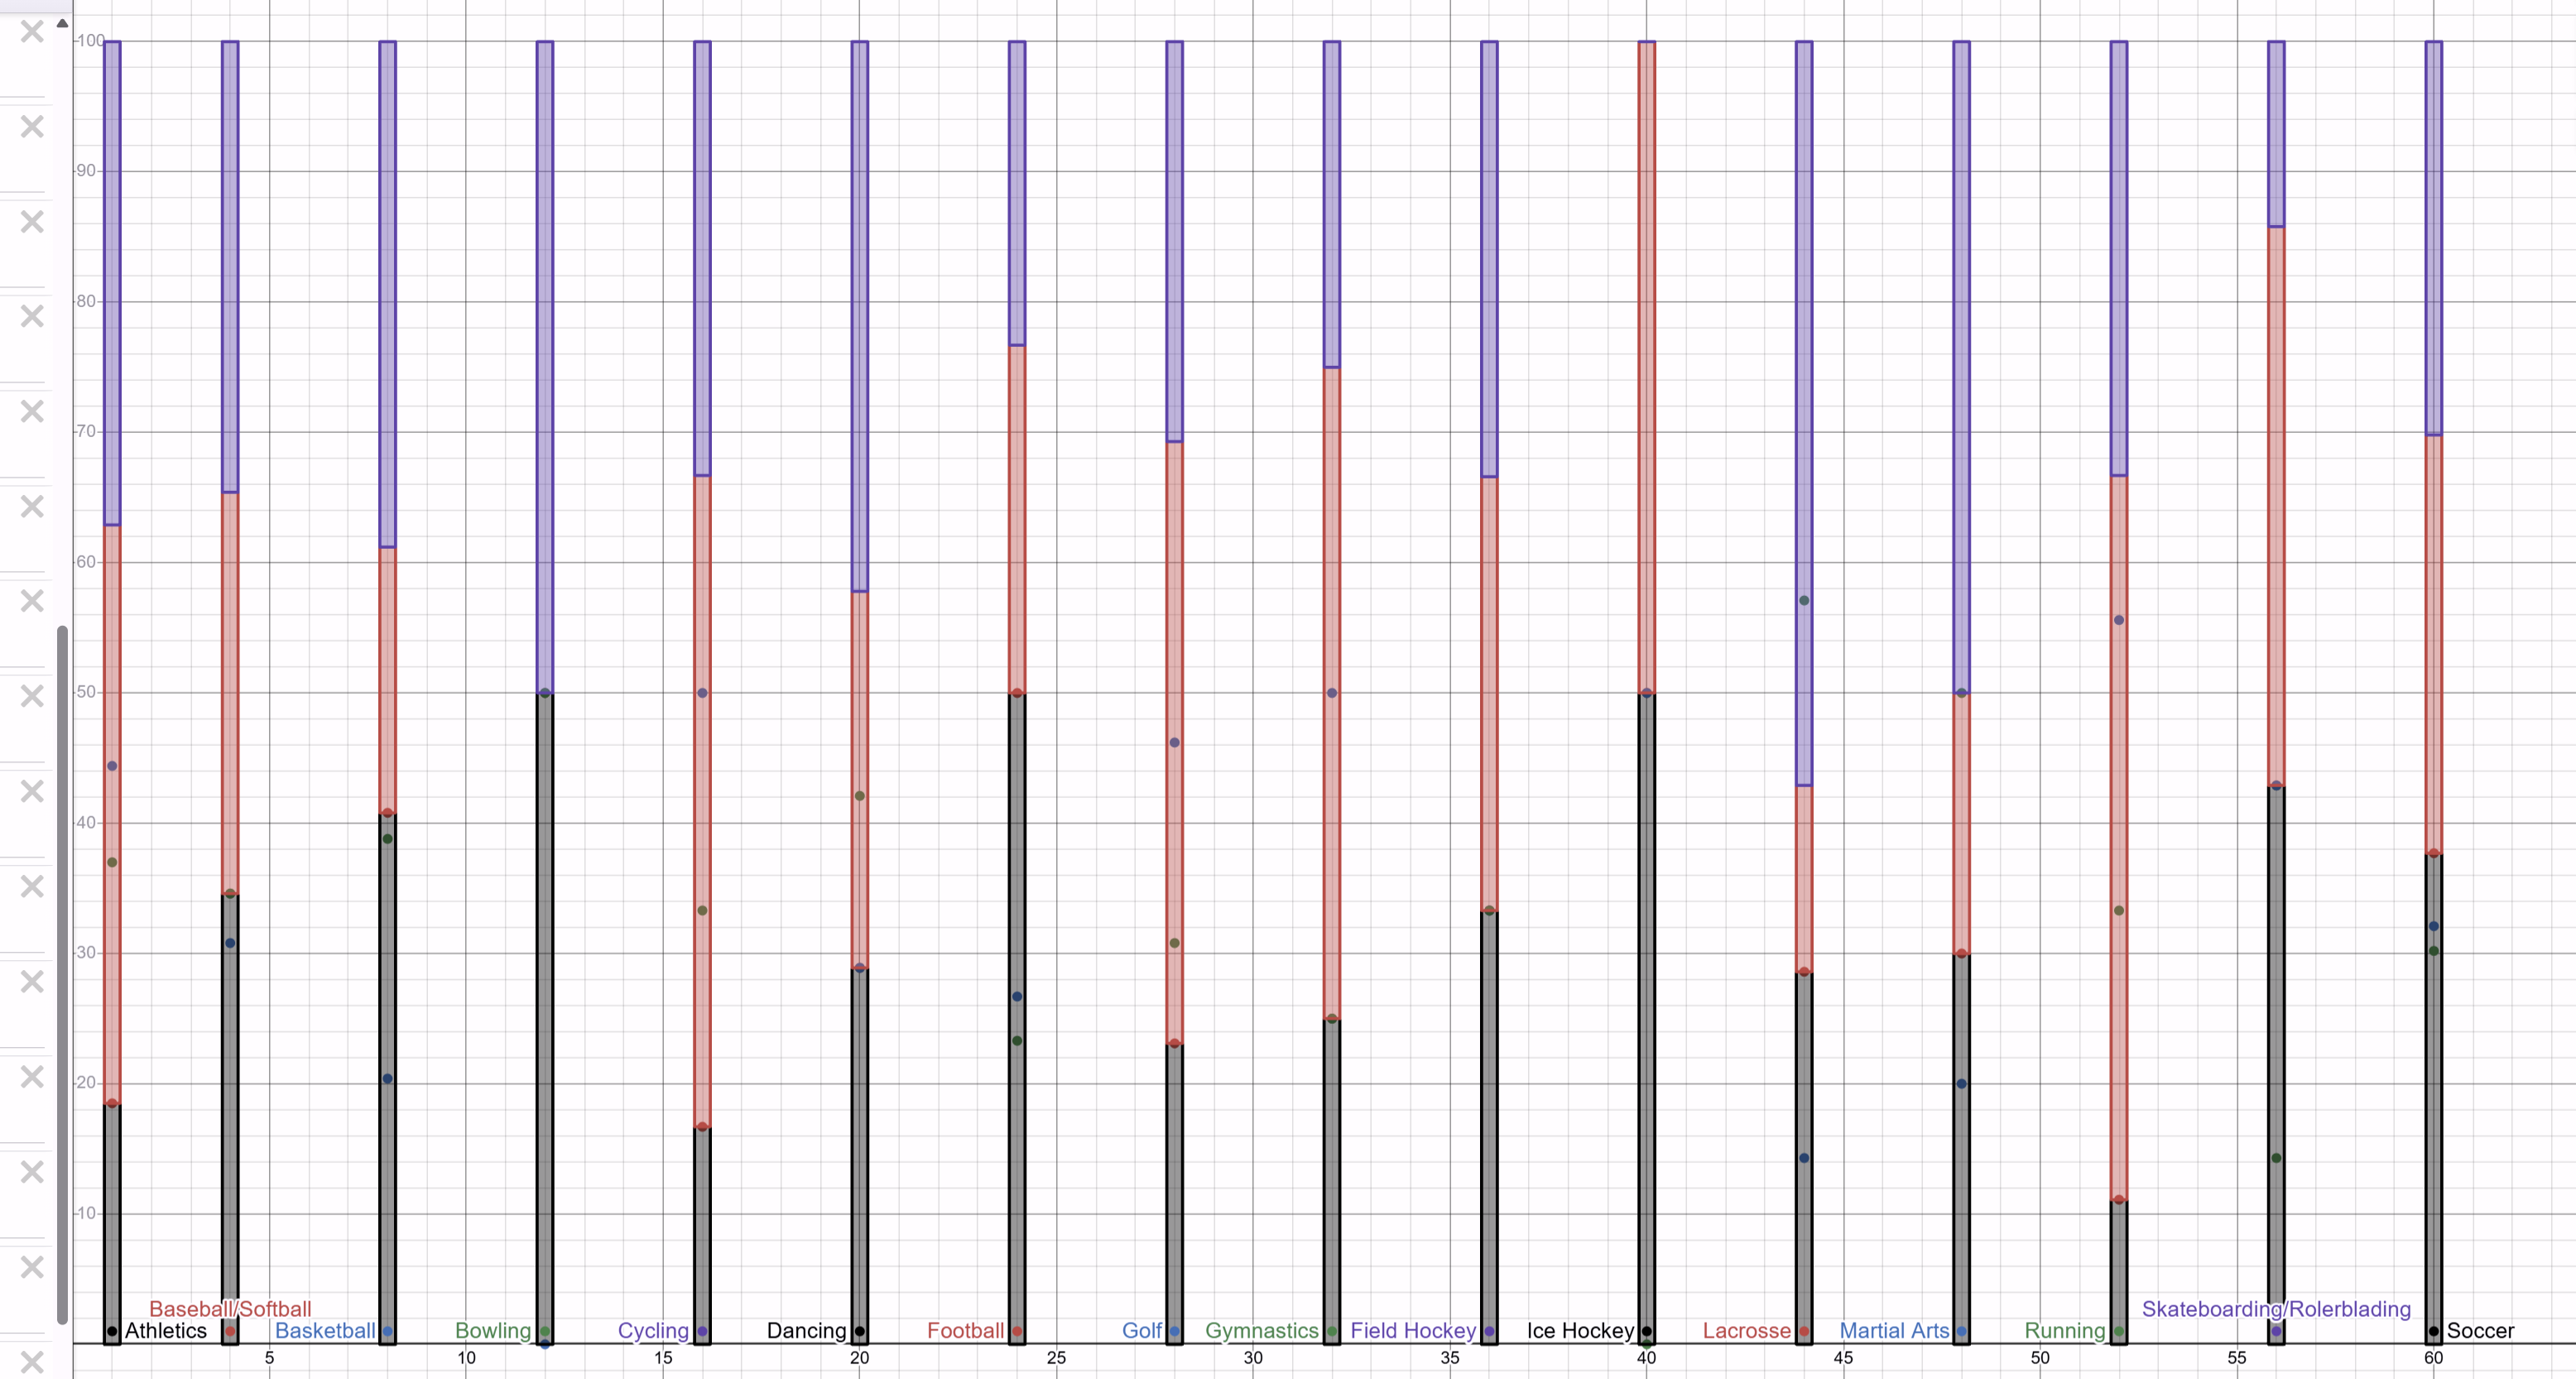

## Analysis
Based on my calculations football and Ice Hockey are the quickest responding sports based on the data. For both sports half the athletes who responded were in the fastest bin that I created. Which is far greater than any other sport recorded. They both have a relative frequency 50%. But to answer my true question It would be very tough to predict someone's reaction time. There is not nearly enough data to be accurate. You can also see in my graph there are no major outliers, my bins are not nearly tigh enough or enough of them to seperate the data and make it make sense to the point where we are capable of predicting a person's sport.
